# Issue #5 — Glowy Sheen, Repurposed

**Pillar:** 5 (trend forecast, with receipts)

**Story:** "Skin tint" isn't disappearing, it's being renamed. The market is adapting to the results it promises, skin that looks
like skin, with products relaunching under a new label every time the last one fades: tinted moisturizer,
BB cream, serum foundation, "skin-like finish." The finish survives. The name never does.

**Scope:**
- Data: first-party Google Trends pull via `trendspy` for "skin tint," "tinted moisturizer," "BB
  cream," and "skin-like finish," cross-referenced against a single-sourced Market Defense/BeautyMatter
  quote.
- Anchor: the crash, not the climb. Search interest for "skin tint" fell -75% in three months
  (60 → 15), after peaking at 100 on April 12, 2026, the final day of Coachella Weekend 1. All three
  active terms peaked on that exact date, direct evidence that the fragmentation is one shared
  phenomenon, not three unrelated trends
- Chart 5.1: Trend data  (notebook: 5.1-trend-data)
  The hero line chart with all four search terms plotted together
- Chart 5.2: Combined cost chart (notebook-5.2-cost-chart)  
  Products analysed, annotated with the British Beauty Council's 2%-cosmetics-overproduction-waste stat as a callout, carrying both the redundant-purchase and waste angles in one visual:   
    - Budget tier: Rimmel, The Ordinary, Maybelline  
    - High-end tier: MAKE UP FOR EVER, Hourglass  

## 1. Setup

In [1]:
# Setup
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

ISSUE = "issue-05"
DATA_OUT = Path(f"../../data/processed/{ISSUE}")
CHART_OUT = Path(f"../../content/posts/{ISSUE}/exports")
DATA_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

## 2. Load Brand Palette

In [2]:
# load brand palette
with open("../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

plt.rcParams["font.family"] = "serif"
plt.rcParams["axes.facecolor"] = COCOA
plt.rcParams["figure.facecolor"] = COCOA
plt.rcParams["text.color"] = CREAM
plt.rcParams["axes.labelcolor"] = CREAM
plt.rcParams["xtick.color"] = CREAM
plt.rcParams["ytick.color"] = CREAM

## 3. Manual inputs

### 3.1 Redundant-Purchase Pricing

The prices are set to USD by default to match BLS/FRED wage-bechmark convention. AUD is included alongside as reference. The prices are from each brand's own published RRP in each country, not a currency conversion. 

In [3]:
# redundant-purchase pricing (RRP), both tiers
products = pd.DataFrame([
    # name, tier, price_usd, price_aud
    {"name": "Rimmel Kind & Free\nSkin Tint",           "tier": "Budget",   "price_usd": 11.00, "price_aud": 21.95},
    {"name": "The Ordinary\nSerum Foundation",           "tier": "Budget",   "price_usd": 7.50,  "price_aud": 12.70},
    {"name": "Maybelline SuperStay\n24hr Skin Tint",     "tier": "Budget",   "price_usd": 17.99, "price_aud": 37.99},
    {"name": "MAKE UP FOR EVER\nHD Skin Balancing &\nPerfecting Foundation", "tier": "High-end", "price_usd": 49.00, "price_aud": 74.00},
    {"name": "Hourglass Veil\nHydrating Skin Tint",      "tier": "High-end", "price_usd": 49.00, "price_aud": 86.00},
])

# sort within tier by price so the bars read low-to-high
products["tier"] = pd.Categorical(products["tier"], categories=["Budget", "High-end"], ordered=True)
products = products.sort_values(["tier", "price_usd"]).reset_index(drop=True)
products

,name,tier,price_usd,price_aud
0,The Ordinary\nSerum Foundation,Budget,7.50,12.70
1,Rimmel Kind & Free\nSkin Tint,Budget,11.00,21.95
2,Maybelline SuperStay\n24hr Skin Tint,Budget,17.99,37.99
3,MAKE UP FOR EVER\nHD Skin Balancing &\nPerfect...,High-end,49.00,74.00
4,Hourglass Veil\nHydrating Skin Tint,High-end,49.00,86.00


### 3.2 Waste/sustainability annotation

According to the British Beauty Council, ~2% of cosmetic items are thrown away due to overproduction. This rate is proven to be higher than fashion, pharmaceutical, food, or the auto industry.

In [4]:
WASTE_STAT_HEADLINE = "2%"
WASTE_STAT_CONTEXT = (
    "of cosmetic items are thrown away\ndue to overproduction, a higher rate than\n"
    "fashion, pharmaceutical, food, or auto"
)
WASTE_STAT_SOURCE = "British Beauty Council"

## 4. Sanity Check

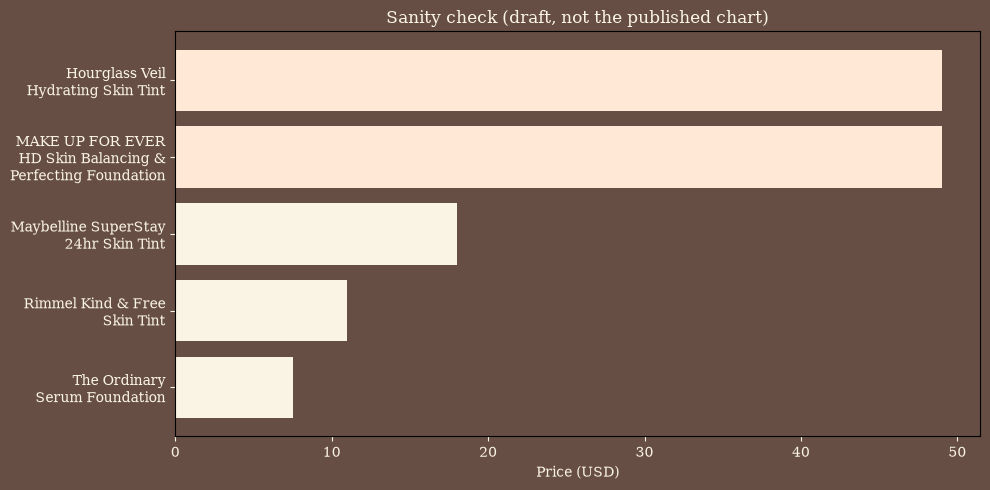

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(products["name"], products["price_usd"], color=[CREAM if t == "Budget" else PEACH for t in products["tier"]])
ax.set_title("Sanity check (draft, not the published chart)")
ax.set_xlabel("Price (USD)")
plt.tight_layout()
plt.show()

## 4. Visualising the combined cost chart

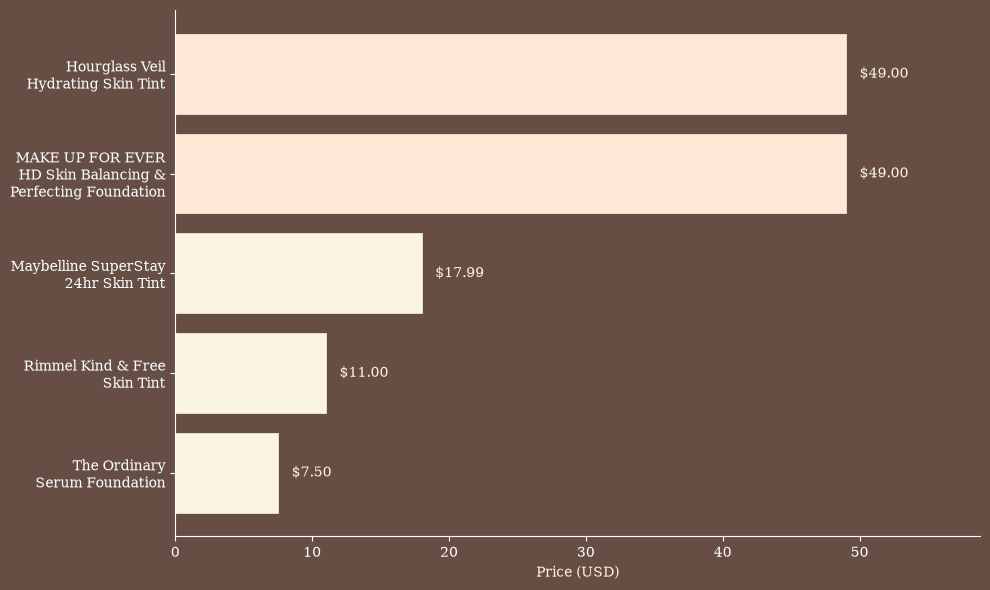

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

bar_colors = [CREAM if t == "Budget" else PEACH for t in products["tier"]]
bars = ax.barh(products["name"], products["price_usd"], color=bar_colors, edgecolor=CREAM, linewidth=0.5)

# Price labels at the end of each bar
for bar, price in zip(bars, products["price_usd"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"${price:,.2f}", va="center", ha="left", color=CREAM, fontsize=10)

ax.set_xlabel("Price (USD)")
ax.set_xlim(0, products["price_usd"].max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("white")
ax.tick_params(axis="both", colors="white")

plt.tight_layout()
plt.show()